<a href="https://colab.research.google.com/github/amrios80/MINE_4206_AML_202610/blob/main/labs/lab_2/MINE_4206_AML_202610_LAB2_Adriana_Rios_Johana_Rios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo ADL](https://github.com/nicolastibata/MINE_4210_ADL_202520/blob/main/docs/images/logo.png?raw=true)


# **Laboratorio 3 - Sesión 1: Redes Neuronales**
**Tutor: Nicolás Tibatá**

## **Tabla de Contenido**

[Contexto y objetivos](#scrollTo=R4YrUaE6udsU&line=14&uniqifier=1)<br>
[1. Introducción de los datos](#scrollTo=VjA8zwzJvmeO&line=1&uniqifier=1)<br>
[2. Preparación y Modelamiento](#scrollTo=kG8XHROzvuEH&line=1&uniqifier=1)<br>
[3. Preguntas](#scrollTo=HnWtjBcSv3yG&line=1&uniqifier=1)<br>


### **Contexto y Objetivos**

**Problema**
- En este problema se busca predecir el nivel de obesidad de un individuo utilizando sus hábitos alimenticios y características físicas para identificar patrones clave.

**Objetivos**
1. Explorar el dataset para entender las variables y la distribución de los niveles de obesidad.
2. Preprocesar los datos para preparar las características de entrada y la variable objetivo para el modelado.
3. Construir y entrenar un modelo de clasificación con Keras o TensorFlow para predecir el nivel de obesidad.


**Datos**

Los datos los puedes consultar [aquí](https://www.kaggle.com/datasets/ruchikakumbhar/obesity-prediction).

### **1. Introducción a los datos**

Este dataset incluye datos para la estimación de los niveles de obesidad en individuos de México, Perú y Colombia, basándose en sus hábitos alimenticios y condición física. Los datos contienen 17 atributos y 2111 registros, etiquetados con la variable de clase Obesity (Nivel de Obesidad), que permite clasificar los datos usando los valores de Peso Insuficiente, Peso Normal, Sobrepeso Nivel I, Sobrepeso Nivel II, Obesidad Tipo I, Obesidad Tipo II y Obesidad Tipo III.

**Detalles de los Datos:**

| Atributo       | Descripción                                                                 |
|----------------|-----------------------------------------------------------------------------|
| Gender         | Género                                                                     |
| Age            | Edad                                                                       |
| Height         | Altura en metros                                                           |
| Weight         | Peso en kgs                                                                |
| family_history | ¿Algún familiar ha sufrido o sufre de sobrepeso?                          |
| FAVC           | ¿Consumes alimentos altos en calorías frecuentemente?                      |
| FCVC           | ¿Sueles comer vegetales en tus comidas?                                    |
| NCP            | ¿Cuántas comidas principales haces al día?                                 |
| CAEC           | ¿Comes algo entre comidas?                                                 |
| SMOKE          | ¿Fumas?                                                                    |
| CH2O           | ¿Cuánta agua bebes al día?                                                 |
| SCC            | ¿Controlas las calorías que consumes diariamente?                          |
| FAF            | ¿Con qué frecuencia realizas actividad física?                             |
| TUE            | ¿Cuánto tiempo usas dispositivos tecnológicos como celular, videojuegos, televisión, computadora y otros? |
| CALC           | ¿Con qué frecuencia consumes alcohol?                                      |
| MTRANS         | ¿Qué transporte utilizas habitualmente?                                    |
| Obesity  | Nivel de Obesidad (Target Variable)                                       |

In [ ]:
# Instalación e Importación de librerías
!pip install keras-tuner -q
!pip install scikeras -q
!pip install ydata-profiling -q

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
from google.colab import userdata
from ydata_profiling import ProfileReport

import tensorflow as tf
import keras_tuner as kt
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.utils import plot_model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

Cargamos los datos directamente de kaggle con las credenciales personales, pueden consultar cómo funciona [acá](https://www.kaggle.com/discussions/general/74235#2580958).

In [ ]:
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

!kaggle datasets download -d ruchikakumbhar/obesity-prediction

! unzip "obesity-prediction.zip"

Dataset URL: https://www.kaggle.com/datasets/ruchikakumbhar/obesity-prediction
License(s): Attribution 4.0 International (CC BY 4.0)
obesity-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  obesity-prediction.zip
replace Obesity prediction.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Obesity prediction.csv  


In [ ]:
data = pd.read_csv("Obesity prediction.csv")
data.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [ ]:
ProfileReport(data)

### **2. Preparación y Modelamiento**

#### **Preparación**

In [ ]:
# Primer Paso: Separar los datos en entrenamiento y test
train_data, test_data = train_test_split(data, test_size=0.2, random_state=71)

# Segundo Paso: Separamos nuestras variables explicativas del target en nuestro set de entrenamiento
X_train, y_train = train_data.drop(['Obesity'], axis=1), train_data['Obesity']
display(X_train.head())
display(y_train.head())

# Tercer Paso: Aplicar onehot a la variable a predecir ya que la tenemos como variable categórica
encoder_y = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder_y.fit_transform(y_train.values.reshape(-1, 1))
display(y_train_encoded)

# Cuarto Paso: Standard Scaler para variables numericas, One hot Encoder para variables categoricas
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns
print(f'Numerical {numeric_features}')
print(f'Categorical {categorical_features}')

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
1756,Male,22.771001,1.865160,121.527369,yes,yes,2.739000,2.740492,Sometimes,no,1.824561,no,1.094839,0.000000,Sometimes,Public_Transportation
476,Female,18.000000,1.710000,75.000000,yes,yes,3.000000,3.000000,Sometimes,no,2.000000,no,1.000000,0.000000,no,Public_Transportation
1582,Male,30.242597,1.759772,118.382361,yes,yes,2.312528,3.000000,Sometimes,no,2.208068,no,1.076720,1.035711,Sometimes,Automobile
1150,Male,19.160970,1.662728,77.473204,yes,no,2.008656,1.402771,Sometimes,no,3.000000,no,0.112383,0.328030,Sometimes,Public_Transportation
1399,Female,23.000000,1.611058,84.191125,yes,yes,2.141280,2.989112,Sometimes,no,2.519841,no,2.111370,0.013483,no,Public_Transportation


,Obesity
1756,Obesity_Type_II
476,Overweight_Level_I
1582,Obesity_Type_II
1150,Overweight_Level_II
1399,Obesity_Type_I


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

Numerical Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')
Categorical Index(['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC',
       'MTRANS'],
      dtype='object')


In [ ]:
# Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_features])
X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_features)

# Onehot encoder
encoder = OneHotEncoder()
X_train_encoded = encoder.fit_transform(X_train[categorical_features])
X_train_encoded = pd.DataFrame(X_train_encoded.toarray(), columns=encoder.get_feature_names_out())

# Concat
X_train_processed = pd.concat([X_train_scaled, X_train_encoded], axis=1)
X_train_processed

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Female,Gender_Male,...,SCC_yes,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,-0.235356,1.740991,1.357966,0.607958,0.078861,-0.288471,0.109078,-1.067178,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.993419,0.075436,-0.445688,1.098052,0.411377,-0.002625,-0.002376,-1.067178,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.951805,0.609711,1.236049,-0.192852,0.411377,0.336385,0.087785,0.623434,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-0.808953,-0.432002,-0.349813,-0.763449,-1.635209,1.626695,-1.045496,-0.531728,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.198970,-0.986650,-0.089390,-0.514414,0.397426,0.844362,1.303696,-1.045169,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1683,-0.742901,1.414181,0.113666,-0.136905,1.191519,1.429329,1.172815,-0.727128,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1684,-0.363614,1.573974,1.389214,1.098052,-0.590262,-1.077785,-0.674281,-1.067178,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1685,1.133795,1.151187,0.727136,-0.033709,-0.822813,1.071780,0.070499,1.823880,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1686,0.429860,0.834693,1.025768,-0.285394,0.411377,0.148102,-1.177567,1.931153,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


Mejor incluyamos los pasos a un [pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), de tal forma los steps en entrenamiento pueden ser facilmente replicables en los datos de test, esto permite una mayor consistencia y claridad de los pasos aplicados en los datos.

In [ ]:
# Pipeline Primer Paso: Se definen los pasos a realizar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Pipeline Segundo Paso: Se aplican esos pasos a las variables explicativas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Pipeline Tercer Paso: Se acopla el preprocesador
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Se aplica el pipeline al set de datos
X_train_processed = full_pipeline.fit_transform(X_train)
print(X_train_processed) # Debemos procesar los datos para que sean un dataframe y no listas de arreglos

[[-0.23535567  1.74099068  1.35796645 ...  0.          1.
   0.        ]
 [-0.99341925  0.07543646 -0.44568832 ...  0.          1.
   0.        ]
 [ 0.95180502  0.60971053  1.23604878 ...  0.          0.
   0.        ]
 ...
 [ 1.13379506  1.1511874   0.72713557 ...  0.          0.
   0.        ]
 [ 0.42985953  0.83469345  1.02576791 ...  0.          0.
   0.        ]
 [ 0.07932725  0.34747913 -0.12247275 ...  0.          1.
   0.        ]]


In [ ]:
# Sacamos los nombres de las columnas y organizamos el Dataframe
numeric_feature_names = numeric_features.tolist()

categorical_feature_names = full_pipeline.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .named_steps['onehot']\
    .get_feature_names_out(categorical_features)

all_feature_names = numeric_feature_names + categorical_feature_names.tolist()
X_train_processed = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_train_processed.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Female,Gender_Male,...,SCC_yes,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,-0.235356,1.740991,1.357966,0.607958,0.078861,-0.288471,0.109078,-1.067178,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.993419,0.075436,-0.445688,1.098052,0.411377,-0.002625,-0.002376,-1.067178,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.951805,0.609711,1.236049,-0.192852,0.411377,0.336385,0.087785,0.623434,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-0.808953,-0.432002,-0.349813,-0.763449,-1.635209,1.626695,-1.045496,-0.531728,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.198970,-0.986650,-0.089390,-0.514414,0.397426,0.844362,1.303696,-1.045169,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


#### **Modelamiento**

Vamos a utilizar la arquitectura de un Perceptron de una sola capa, la cual se ve de la siguiente manera para este caso:

![Multilayer Perceptron](https://github.com/nicolastibata/MINE_4210_ADL_202520/blob/main/docs/images/MLP%20Lab1.png?raw=true)

Para ello, lo primero que definiremos será nuestro modelo.


---

La libreria Keras nos permite crear modelos secuenciales mediante la clase `Sequential`, primero definimos el modelo y le asignamos un nombre, seguido se usa el método `add` para ir adicionando las capas que vamos requiriendo.

> La primera capa, que corresponde a la capa de entrada (**Input Layer**), se debe especificar con el número de neuronas que corresponde al número de características que vamos a tener en nuestro modelo, en este caso nuestros datos en X contienen 31 columnas o variables explicativas, por ende se requieren 31 neuronas. Una forma general de definirlo es usando el método shape: X.shape[1]

> Seguido a la capa de entrada agregamos una capa de tipo **Dense**, que será nuestra capa oculta, la cual inicialmente asignaremos 4 neuronas y utilizará la función de activación RELU.

> Finalmente, se adiciona la capa de salida (también de tipo Dense pero con función de activación SOFTMAX), que nos dará el resultado de las predicciones de nuestro modelo. En este caso con 7 neuronas, haciendo referencia a las 7 posibles segmentaciones del nivel de obesidad.


In [ ]:
model = Sequential(name="Mi_primer_MLP")

model.add(Input(shape=(X_train_processed.shape[1],), name='Input_Layer'))
model.add(Dense(4,activation='relu',name='Hidden_Layer'))
model.add(Dense(7,activation='softmax',name='Output_Layer'))

El método `compile` permite configurar nuestro modelo para el entrenamiento. Este método acepta varios argumentos, como el *optimizer*, el *loss* y las *metrics*, que se utilizan para optimizar los pesos del modelo durante el entrenamiento.

In [ ]:
model.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

model.summary()

Model: "Mi_primer_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer (Dense)            │ (None, 4)              │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 7)              │            35 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163 (652.00 B)

 Trainable params: 163 (652.00 B)

 Non-trainable params: 0 (0.00 B)

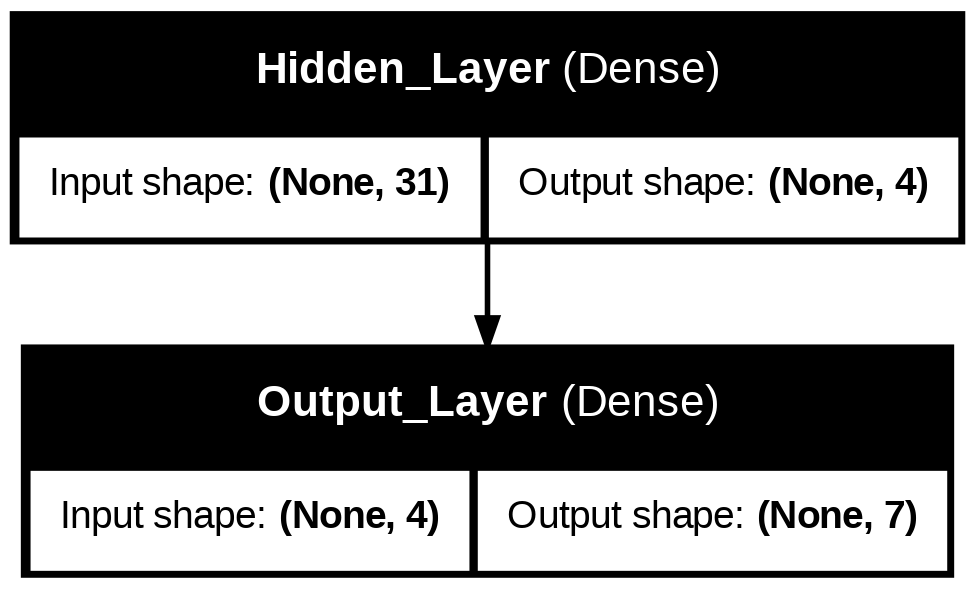

In [ ]:
plot_model(model, show_shapes=True, show_layer_names=True)

In [ ]:
%%time
history = model.fit(
    X_train_processed,
    y_train_encoded,
    batch_size=10,
    epochs=50
)

Epoch 1/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1682 - loss: 2.0097
Epoch 2/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2330 - loss: 1.8451
Epoch 3/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3229 - loss: 1.7519
Epoch 4/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3596 - loss: 1.6327
Epoch 5/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4155 - loss: 1.5594
Epoch 6/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4383 - loss: 1.4986
Epoch 7/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4672 - loss: 1.4353
Epoch 8/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5022 - loss: 1.3590
Epoch 9/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5308 - loss: 1.3112
Epoch 10/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5487 - loss: 1.2574
Epoch 11/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5680 - loss: 1.1969
Epoch 12/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

**Evaluamos nuestro modelo con los datos de entrenamiento**

In [ ]:
loss, accuracy = model.evaluate(X_train_processed, y_train_encoded)
print(f'Loss: {loss}, Accuracy: {accuracy}')

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8724 - loss: 0.3898
Loss: 0.3718799650669098, Accuracy: 0.8761848211288452


In [ ]:
y_pred = model.predict(X_train_processed)
y_pred_classes = y_pred.argmax(axis=1) # Por qué Argmax?
y_pred_classes

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([3, 0, 3, ..., 2, 3, 5])

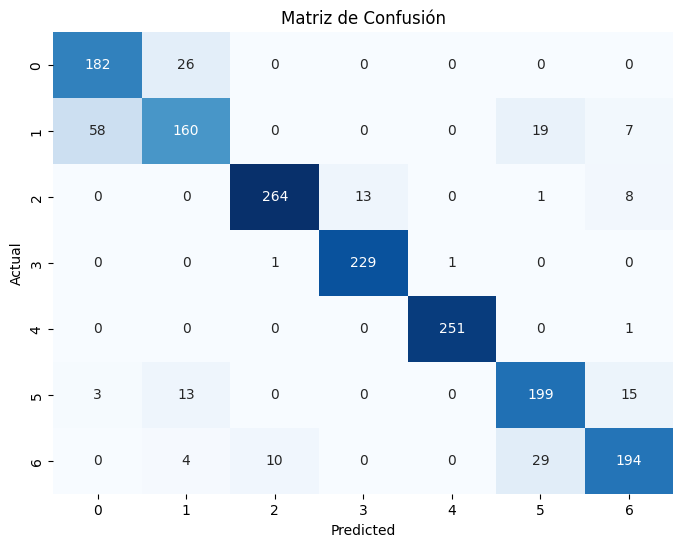

In [ ]:
# Convert one-hot to class index
y_train_classes = y_train_encoded.argmax(axis=1)

cm = confusion_matrix(y_train_classes, y_pred_classes)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión')
plt.show()

In [ ]:
print(classification_report(y_train_classes, y_pred_classes))

              precision    recall  f1-score   support

           0       0.75      0.88      0.81       208
           1       0.79      0.66      0.72       244
           2       0.96      0.92      0.94       286
           3       0.95      0.99      0.97       231
           4       1.00      1.00      1.00       252
           5       0.80      0.87      0.83       230
           6       0.86      0.82      0.84       237

    accuracy                           0.88      1688
   macro avg       0.87      0.87      0.87      1688
weighted avg       0.88      0.88      0.87      1688



**Ahora evaluemos el modelo con los datos de test**

In [ ]:
X_test, y_test = test_data.drop(['Obesity'], axis=1), test_data['Obesity']
display(X_test.head())
display(y_test.head())
# Recordemos transformar nuestra variable y_train con onehot
y_test_encoded = encoder_y.transform(y_test.values.reshape(-1, 1))
display(y_test_encoded)

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
1022,Female,23.469538,1.507106,64.814109,yes,no,2.252472,3.986652,Sometimes,no,2.000000,no,0.934286,0.890626,no,Public_Transportation
558,Male,17.486869,1.836669,58.943347,yes,yes,2.767731,3.821168,Sometimes,no,2.000000,no,2.000000,0.556245,no,Automobile
636,Female,19.054008,1.556611,39.695295,no,yes,1.889199,2.217651,Sometimes,no,2.013605,no,2.075293,1.683261,Sometimes,Public_Transportation
1536,Male,25.154620,1.758398,112.089022,yes,yes,1.108663,3.000000,Sometimes,no,2.000000,no,1.230219,0.001716,Sometimes,Automobile
52,Female,23.000000,1.640000,52.000000,no,yes,3.000000,1.000000,Sometimes,no,2.000000,no,2.000000,2.000000,no,Public_Transportation


,Obesity
1022,Overweight_Level_II
558,Insufficient_Weight
636,Insufficient_Weight
1536,Obesity_Type_II
52,Normal_Weight


array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [ ]:
# Apliquemos el pipeline para ahorrarnos pasos
X_test_processed = full_pipeline.transform(X_test)
X_test_processed = pd.DataFrame(X_test_processed, columns=all_feature_names)
X_test_processed.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Female,Gender_Male,...,SCC_yes,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,-0.124365,-2.102515,-0.840549,-0.305623,1.675610,-0.002625,-0.079603,0.386608,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-1.074951,1.435156,-1.068132,0.661907,1.463569,-0.002625,1.172815,-0.159208,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,-0.825948,-1.571107,-1.814291,-0.987760,-0.591074,0.019542,1.261299,1.680442,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.143377,0.594961,0.992085,-2.453416,0.411377,-0.002625,0.268175,-1.064376,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,-0.198970,-0.675974,-1.337294,1.098052,-2.151294,-0.002625,1.172815,2.197461,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
y_pred = model.predict(X_test_processed)
y_pred_classes = y_pred.argmax(axis=1)
y_pred_classes

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([6, 0, 0, 2, 0, 3, 6, 4, 2, 3, 0, 0, 5, 6, 1, 1, 0, 3, 4, 4, 2, 3,
       2, 6, 4, 0, 6, 4, 5, 3, 0, 0, 5, 0, 1, 1, 3, 2, 1, 2, 5, 0, 4, 6,
       0, 3, 2, 6, 0, 4, 3, 2, 2, 2, 5, 5, 4, 6, 0, 0, 6, 5, 0, 4, 2, 3,
       4, 4, 1, 6, 3, 0, 1, 3, 6, 5, 6, 5, 6, 4, 6, 6, 6, 1, 3, 2, 3, 2,
       1, 3, 4, 4, 5, 3, 4, 1, 3, 4, 5, 5, 3, 2, 2, 1, 6, 1, 2, 5, 2, 0,
       1, 6, 0, 5, 6, 5, 1, 2, 3, 4, 3, 4, 1, 2, 2, 5, 2, 3, 0, 4, 5, 5,
       3, 0, 4, 5, 1, 5, 2, 2, 0, 5, 0, 0, 6, 5, 0, 2, 6, 3, 6, 4, 0, 5,
       6, 0, 6, 5, 1, 5, 4, 5, 4, 4, 3, 5, 4, 5, 1, 2, 5, 6, 4, 5, 4, 0,
       4, 1, 0, 3, 2, 6, 3, 2, 5, 2, 6, 4, 0, 3, 5, 0, 2, 3, 0, 5, 3, 5,
       5, 1, 0, 0, 3, 4, 5, 0, 6, 3, 2, 2, 0, 6, 2, 5, 0, 5, 2, 0, 3, 4,
       2, 4, 5, 5, 2, 4, 1, 5, 2, 4, 3, 3, 4, 5, 2, 3, 4, 6, 4, 5, 5, 1,
       2, 5, 4, 1, 3, 1, 3, 1, 2, 0, 3, 5, 2, 0, 5, 5, 2, 3, 4, 0, 4, 6,
       5, 5, 0, 4, 3, 4, 3, 2, 4, 1, 1, 2, 5, 0, 3, 1, 4, 2, 5, 1, 0, 6,
       4, 3, 1, 3, 2, 6, 5, 2, 0, 4, 6, 4, 0, 4, 3,

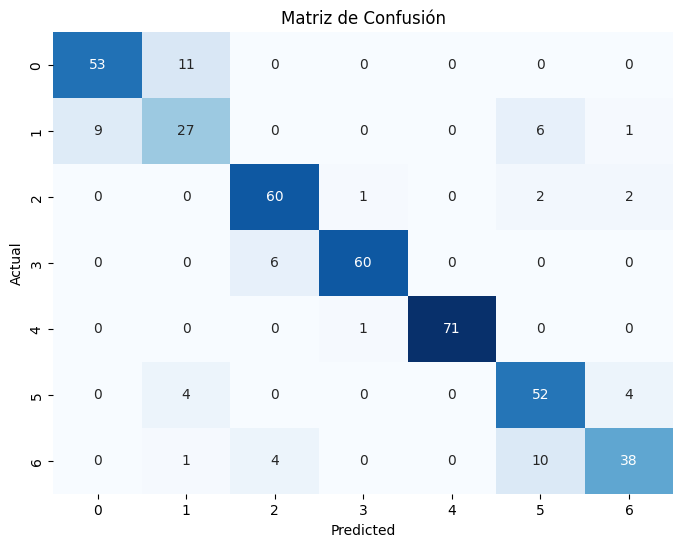

In [ ]:
y_test_classes = y_test_encoded.argmax(axis=1)

cm = confusion_matrix(y_test_classes, y_pred_classes)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión')
plt.show()

In [ ]:
print(classification_report(y_test_classes, y_pred_classes))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84        64
           1       0.63      0.63      0.63        43
           2       0.86      0.92      0.89        65
           3       0.97      0.91      0.94        66
           4       1.00      0.99      0.99        72
           5       0.74      0.87      0.80        60
           6       0.84      0.72      0.78        53

    accuracy                           0.85       423
   macro avg       0.84      0.84      0.84       423
weighted avg       0.86      0.85      0.85       423



### **3. Preguntas**

1. ¿Qué otras opciones de transformación de los datos existen? ¿Cuáles usarían en este caso y por qué?
-

2. ¿De qué depende la cantidad de neuronas en la capa de salida?
-

3. ¿Cómo definir el número de capas ocultas y el número de neuronas por capa?
-